# Classification Layer - DeepFashion2

**End-to-End Classification Pipeline**

Pipeline Flow:
1. Load part-aware features (2048-D) from PartAwarePooling
2. Pass through meta-learning projection head (2048 → 512)
3. Classify with trainable head (512 → 13 classes)
4. Train with Adam + Cosine LR scheduling

**Training on full dataset: 312,186 train + 52,490 validation samples**

## Step 1: Imports and Configuration

In [1]:
import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import matplotlib.pyplot as plt

# Configuration
ROOT_DIR = "/home/vishn/Documents/5/ML/Code/Project"
OUTPUT_DIR = os.path.join(ROOT_DIR, "output")
PARTAWARE_DIR = os.path.join(OUTPUT_DIR, "PartAwarePooling")
INPUT_DIR = os.path.join(OUTPUT_DIR, "input")
CHECKPOINT_DIR = os.path.join(ROOT_DIR, "checkpoints")
os.makedirs(CHECKPOINT_DIR, exist_ok=True)

META_MODEL_PATH = os.path.join(ROOT_DIR, "best_meta_model.pt")
CLASSIFIER_PATH = os.path.join(CHECKPOINT_DIR, "classifier_head.pth")

# Hyperparameters
NUM_CLASSES = 13
EMBED_DIM = 512
INPUT_DIM = 2048
BATCH_SIZE = 32
NUM_EPOCHS = 10
LEARNING_RATE = 1e-4
DROPOUT = 0.5

# Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("="*80)
print("CLASSIFICATION LAYER - DEEPFASHION2")
print("="*80)
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"CUDA Version: {torch.version.cuda}")
print(f"\nHyperparameters:")
print(f"  Batch size: {BATCH_SIZE}")
print(f"  Epochs: {NUM_EPOCHS}")
print(f"  Learning rate: {LEARNING_RATE}")
print(f"  Dropout: {DROPOUT}")
print("="*80)

CLASSIFICATION LAYER - DEEPFASHION2
Device: cuda
GPU: NVIDIA GeForce GTX 1650
CUDA Version: 12.8

Hyperparameters:
  Batch size: 32
  Epochs: 10
  Learning rate: 0.0001
  Dropout: 0.5


## Step 2: Load Data (Full Dataset)

In [2]:
print("\n" + "="*80)
print("LOADING DEEPFASHION2 DATA")
print("="*80)

# Load part-aware fused features (raw binary float32 files)
print("\n[1/3] Loading features...")
train_file = os.path.join(PARTAWARE_DIR, "train_fused_features.npy")
val_file = os.path.join(PARTAWARE_DIR, "val_fused_features.npy")

train_features = np.fromfile(train_file, dtype=np.float32).reshape(312186, 2048)
val_features = np.fromfile(val_file, dtype=np.float32).reshape(52490, 2048)
print(f"  Train features: {train_features.shape}")
print(f"  Val features: {val_features.shape}")

# Load labels and convert to 0-indexed (PyTorch expects 0-12, not 1-13)
print("\n[2/3] Loading labels...")
train_df = pd.read_csv(os.path.join(INPUT_DIR, "train.csv"))
val_df = pd.read_csv(os.path.join(INPUT_DIR, "validation.csv"))
train_labels = train_df['category_id'].values - 1  # Convert 1-13 to 0-12
val_labels = val_df['category_id'].values - 1
print(f"  Train labels: {len(train_labels)} samples (range: {train_labels.min()}-{train_labels.max()})")
print(f"  Val labels: {len(val_labels)} samples (range: {val_labels.min()}-{val_labels.max()})")

# Convert to tensors
print("\n[3/3] Converting to tensors...")
train_features_t = torch.from_numpy(train_features).float()
train_labels_t = torch.from_numpy(train_labels).long()
val_features_t = torch.from_numpy(val_features).float()
val_labels_t = torch.from_numpy(val_labels).long()

# Create dataloaders
train_dataset = TensorDataset(train_features_t, train_labels_t)
val_dataset = TensorDataset(val_features_t, val_labels_t)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, 
                          num_workers=4, pin_memory=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, 
                        num_workers=4, pin_memory=True)

print(f"  ✓ Train loader: {len(train_loader)} batches")
print(f"  ✓ Val loader: {len(val_loader)} batches")
print("\n" + "="*80)
print(f"✅ DATA LOADED: {len(train_features_t):,} train + {len(val_features_t):,} val")
print("="*80)


LOADING DEEPFASHION2 DATA

[1/3] Loading features...
  Train features: (312186, 2048)
  Val features: (52490, 2048)

[2/3] Loading labels...
  Train labels: 312186 samples (range: 0-12)
  Val labels: 52490 samples (range: 0-12)

[3/3] Converting to tensors...
  ✓ Train loader: 9756 batches
  ✓ Val loader: 1641 batches

✅ DATA LOADED: 312,186 train + 52,490 val


## Step 3: Define Models and Functions

In [3]:
# Meta-learning projection head (2048 -> 512)
def create_projection_head(input_dim=2048, embed_dim=512, hidden_dim=1024, dropout=0.3):
    """Project features to embeddings with L2 normalization."""
    return nn.Sequential(
        nn.Linear(input_dim, hidden_dim),
        nn.BatchNorm1d(hidden_dim),
        nn.ReLU(inplace=True),
        nn.Dropout(p=dropout),
        nn.Linear(hidden_dim, embed_dim)
    )

def apply_projection(model, features):
    """Apply projection with L2 normalization."""
    embeddings = model(features)
    return F.normalize(embeddings, p=2, dim=1)

# Classification head (512 -> 13)
def build_classifier(input_dim, num_classes=13, dropout=0.5):
    """
    Classification head with BatchNorm + Dropout + Linear.
    
    - BatchNorm: Normalizes embeddings for stable training
    - Dropout(0.5): Prevents overfitting on imbalanced DeepFashion2
    - Linear: Projects to 13 category logits
    """
    return nn.Sequential(
        nn.BatchNorm1d(input_dim),
        nn.Dropout(p=dropout),
        nn.Linear(input_dim, num_classes)
    )

print("✓ Model functions defined")

✓ Model functions defined


## Step 4: Load Pre-trained Models

In [4]:
print("\n" + "="*80)
print("LOADING MODELS")
print("="*80)

# Load projection head from meta-learning
projection_head = create_projection_head(INPUT_DIM, EMBED_DIM).to(device)
if os.path.exists(META_MODEL_PATH):
    projection_head.load_state_dict(torch.load(META_MODEL_PATH, map_location=device))
    print(f"✓ Loaded meta-learning projection head")
else:
    print(f"⚠ Meta-learning weights not found, using random initialization")

# Freeze projection head (only train classifier)
for param in projection_head.parameters():
    param.requires_grad = False
projection_head.eval()
print(f"  → Projection head frozen (trainable params: 0)")

# Create classifier
classifier = build_classifier(EMBED_DIM, NUM_CLASSES, DROPOUT).to(device)
num_params = sum(p.numel() for p in classifier.parameters() if p.requires_grad)
print(f"✓ Created classifier head")
print(f"  → Trainable parameters: {num_params:,}")

print("="*80)


LOADING MODELS
✓ Loaded meta-learning projection head
  → Projection head frozen (trainable params: 0)
✓ Created classifier head
  → Trainable parameters: 7,693


## Step 5: Training Setup

In [5]:
# Optimizer and scheduler
optimizer = torch.optim.Adam(classifier.parameters(), lr=LEARNING_RATE)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=NUM_EPOCHS, eta_min=1e-6)

# Training history
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [], 'lr': []}
best_val_acc = 0.0

print(f"\n✓ Optimizer: Adam (lr={LEARNING_RATE})")
print(f"✓ Scheduler: CosineAnnealingLR (T_max={NUM_EPOCHS})")
print(f"✓ Loss: CrossEntropyLoss")


✓ Optimizer: Adam (lr=0.0001)
✓ Scheduler: CosineAnnealingLR (T_max=10)
✓ Loss: CrossEntropyLoss


## Step 6: Train on Full Dataset

**Pipeline per batch:**
1. Load features [B, 2048]
2. Project through frozen head → [B, 512]
3. Classify → [B, 13]
4. Compute loss & backprop

In [6]:
def train_epoch(proj_head, classifier, loader, optimizer, device):
    """Train for one epoch."""
    proj_head.eval()
    classifier.train()
    
    total_loss, correct, total = 0.0, 0, 0
    
    for features, labels in tqdm(loader, desc="Training", leave=False):
        features, labels = features.to(device), labels.to(device)
        
        # Forward: features -> embeddings -> logits
        with torch.no_grad():
            embeddings = apply_projection(proj_head, features)
        
        logits = classifier(embeddings)
        loss = F.cross_entropy(logits, labels)
        
        # Backward
        optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(classifier.parameters(), max_norm=1.0)
        optimizer.step()
        
        # Metrics
        total_loss += loss.item()
        _, predicted = torch.max(logits, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
    
    return total_loss / len(loader), 100.0 * correct / total

def validate(proj_head, classifier, loader, device):
    """Validate on validation set."""
    proj_head.eval()
    classifier.eval()
    
    total_loss, correct, total = 0.0, 0, 0
    
    with torch.no_grad():
        for features, labels in tqdm(loader, desc="Validation", leave=False):
            features, labels = features.to(device), labels.to(device)
            
            embeddings = apply_projection(proj_head, features)
            logits = classifier(embeddings)
            loss = F.cross_entropy(logits, labels)
            
            total_loss += loss.item()
            _, predicted = torch.max(logits, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    
    return total_loss / len(loader), 100.0 * correct / total

# Training loop
print("\n" + "="*80)
print(f"TRAINING ON FULL DATASET ({len(train_features_t):,} samples)")
print("="*80)

for epoch in range(1, NUM_EPOCHS + 1):
    print(f"\nEpoch {epoch}/{NUM_EPOCHS}")
    print("-" * 80)
    
    # Train and validate
    train_loss, train_acc = train_epoch(projection_head, classifier, train_loader, optimizer, device)
    val_loss, val_acc = validate(projection_head, classifier, val_loader, device)
    
    # Update learning rate
    current_lr = optimizer.param_groups[0]['lr']
    scheduler.step()
    
    # Save history
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    history['lr'].append(current_lr)
    
    # Print results
    print(f"Train → Loss: {train_loss:.4f} | Acc: {train_acc:.2f}%")
    print(f"Val   → Loss: {val_loss:.4f} | Acc: {val_acc:.2f}%")
    print(f"LR: {current_lr:.6f}")
    
    # Save best model
    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(classifier.state_dict(), CLASSIFIER_PATH)
        print(f"✓ Saved best model (Val Acc: {val_acc:.2f}%)")

print("\n" + "="*80)
print("TRAINING COMPLETE!")
print("="*80)
print(f"Best Val Accuracy: {best_val_acc:.2f}%")
print(f"Model saved: {CLASSIFIER_PATH}")
print("="*80)


TRAINING ON FULL DATASET (312,186 samples)

Epoch 1/10
--------------------------------------------------------------------------------


Train → Loss: 1.9832 | Acc: 30.44%
Val   → Loss: 1.7961 | Acc: 34.28%
LR: 0.000100
✓ Saved best model (Val Acc: 34.28%)

Epoch 2/10
--------------------------------------------------------------------------------


Train → Loss: 1.8896 | Acc: 32.43%
Val   → Loss: 1.7931 | Acc: 33.97%
LR: 0.000098

Epoch 3/10
--------------------------------------------------------------------------------


Train → Loss: 1.8803 | Acc: 32.71%
Val   → Loss: 1.7807 | Acc: 35.08%
LR: 0.000091
✓ Saved best model (Val Acc: 35.08%)

Epoch 4/10
--------------------------------------------------------------------------------


Train → Loss: 1.8781 | Acc: 32.66%
Val   → Loss: 1.7908 | Acc: 34.63%
LR: 0.000080

Epoch 5/10
--------------------------------------------------------------------------------


...

Train → Loss: 1.8739 | Acc: 32.89%
Val   → Loss: 1.7803 | Acc: 35.21%
LR: 0.000051
✓ Saved best model (Val Acc: 35.21%)

Epoch 7/10
--------------------------------------------------------------------------------


Train → Loss: 1.8723 | Acc: 32.91%
Val   → Loss: 1.7838 | Acc: 34.80%
LR: 0.000035

Epoch 8/10
--------------------------------------------------------------------------------


Train → Loss: 1.8711 | Acc: 33.07%
Val   → Loss: 1.7867 | Acc: 34.68%
LR: 0.000021

Epoch 9/10
--------------------------------------------------------------------------------


Train → Loss: 1.8709 | Acc: 32.97%
Val   → Loss: 1.7801 | Acc: 35.18%
LR: 0.000010

Epoch 10/10
--------------------------------------------------------------------------------


Train → Loss: 1.8710 | Acc: 33.01%
Val   → Loss: 1.7893 | Acc: 34.53%
LR: 0.000003

TRAINING COMPLETE!
Best Val Accuracy: 35.21%
Model saved: /home/vishn/Documents/5/ML/Code/Project/checkpoints/classifier_head.pth


## Step 7: Visualize Results

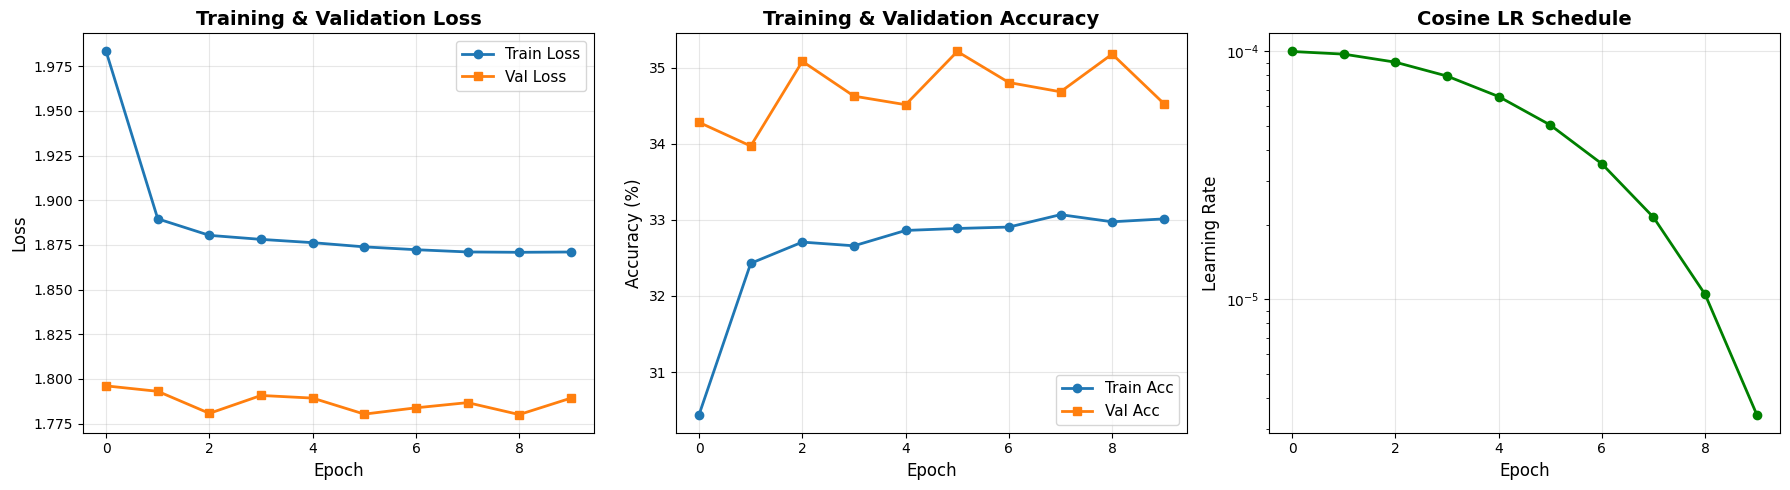


FINAL RESULTS
Final Train Acc: 33.01%
Final Val Acc: 34.53%
Best Val Acc: 35.21%

✓ Training curves saved to: /home/vishn/Documents/5/ML/Code/Project/checkpoints/training_curves.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Loss curves
axes[0].plot(history['train_loss'], label='Train Loss', marker='o', linewidth=2)
axes[0].plot(history['val_loss'], label='Val Loss', marker='s', linewidth=2)
axes[0].set_xlabel('Epoch', fontsize=12)
axes[0].set_ylabel('Loss', fontsize=12)
axes[0].set_title('Training & Validation Loss', fontsize=14, fontweight='bold')
axes[0].legend(fontsize=11)
axes[0].grid(True, alpha=0.3)

# Accuracy curves
axes[1].plot(history['train_acc'], label='Train Acc', marker='o', linewidth=2)
axes[1].plot(history['val_acc'], label='Val Acc', marker='s', linewidth=2)
axes[1].set_xlabel('Epoch', fontsize=12)
axes[1].set_ylabel('Accuracy (%)', fontsize=12)
axes[1].set_title('Training & Validation Accuracy', fontsize=14, fontweight='bold')
axes[1].legend(fontsize=11)
axes[1].grid(True, alpha=0.3)

# Learning rate schedule
axes[2].plot(history['lr'], marker='o', color='green', linewidth=2)
axes[2].set_xlabel('Epoch', fontsize=12)
axes[2].set_ylabel('Learning Rate', fontsize=12)
axes[2].set_title('Cosine LR Schedule', fontsize=14, fontweight='bold')
axes[2].grid(True, alpha=0.3)
axes[2].set_yscale('log')

plt.tight_layout()
plt.savefig(os.path.join(CHECKPOINT_DIR, 'training_curves.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "="*80)
print("FINAL RESULTS")
print("="*80)
print(f"Final Train Acc: {history['train_acc'][-1]:.2f}%")
print(f"Final Val Acc: {history['val_acc'][-1]:.2f}%")
print(f"Best Val Acc: {best_val_acc:.2f}%")
print(f"\n✓ Training curves saved to: {CHECKPOINT_DIR}/training_curves.png")
print("="*80)